In [2]:
# Import necessary libraries
import pandas as pd
from scipy.stats import fisher_exact
import numpy as np

In [ ]:
# Annotate mutations with OS and PFI
os_df = pd.read_csv('BENG_285_team3/proj_4/TCGA_LUAD_final_for_OS_model.csv')
!tar -xvzf 'BENG_285_team3/proj_4/raw_mutations_PASS_only.csv.gz'
mut_df = pd.read_csv('BENG_285_team3/proj_4/raw_mutations_PASS_only.csv')
# os_mut_df = mut_df.merge(os_df, left_on='patient_id', right_index = True, how='left')

/var/folders/1c/p3sgf2gd2r50t_csxf8vrdv80000gn/T/ipykernel_30021/3923821396.py:3: DtypeWarning: Columns (5,53) have mixed types. Specify dtype option on import or set low_memory=False.
  mut_df = pd.read_csv('/Users/aleyshachen/BENG_285/proj_4/raw_mutations_PASS_only.csv')


In [5]:
mut_df

,patient_id,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,...,hg38_Start_Position,hg38_End_Position,hg38_Reference_Allele,hg38_Tumor_Seq_Allele1,hg38_Tumor_Seq_Allele2,gpn_score,GPN-MSA_gene_score,am_mean_gene_pathogenicity,am_pathogenicity,am_class
0,TCGA-78-7150,FAM41C,0,.,GRCh37,1,809715,809715,+,5'Flank,...,874335,874335,G,G,A,-3.68,NaN,NaN,NaN,NaN
1,TCGA-53-A4EZ,OR4F5,0,.,GRCh37,1,69744,69744,+,Missense_Mutation,...,69744,69744,C,C,G,-5.16,NaN,0.270237,0.1393,benign
2,TCGA-62-8399,AJAP1,0,.,GRCh37,1,4715466,4715466,+,5'UTR,...,4655406,4655406,C,C,G,-1.95,0.213456,NaN,NaN,NaN
3,TCGA-55-5899,PRDM16,0,.,GRCh37,1,3103017,3103017,+,Missense_Mutation,...,3186453,3186453,G,G,T,-8.19,0.610690,0.414675,0.3871,ambiguous
4,TCGA-44-3918,AJAP1,0,.,GRCh37,1,4772510,4772510,+,Missense_Mutation,...,4712450,4712450,T,T,A,-6.19,0.213456,NaN,0.0822,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196424,TCGA-MP-A4T4,L1CAM,0,.,GRCh37,X,153132121,153132121,+,Missense_Mutation,...,153866666,153866666,C,C,T,-10.15,0.806045,0.502865,0.9396,pathogenic
196425,TCGA-MP-A4TC,PDZD4,0,.,GRCh37,X,153068880,153068880,+,Missense_Mutation,...,153803425,153803425,C,C,T,-7.25,0.769625,0.434113,0.9281,pathogenic
196426,TCGA-MP-A4TC,PDZD4,0,.,GRCh37,X,153070161,153070161,+,Silent,...,153804706,153804706,C,C,G,-3.48,0.769625,0.434113,NaN,NaN
196427,TCGA-MP-A4TF,PLXNB3,0,.,GRCh37,X,153033039,153033039,+,Missense_Mutation,...,153767584,153767584,G,G,A,-5.01,0.779279,NaN,0.0775,benign


In [6]:
# Subset mut_df to only contain patients with survival data
shared_patients = list(set(os_df.patient_id).intersection(set(mut_df.patient_id)))
mut_df = mut_df[mut_df['patient_id'].isin(shared_patients)]
mut_df

,patient_id,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,...,hg38_Start_Position,hg38_End_Position,hg38_Reference_Allele,hg38_Tumor_Seq_Allele1,hg38_Tumor_Seq_Allele2,gpn_score,GPN-MSA_gene_score,am_mean_gene_pathogenicity,am_pathogenicity,am_class
0,TCGA-78-7150,FAM41C,0,.,GRCh37,1,809715,809715,+,5'Flank,...,874335,874335,G,G,A,-3.68,NaN,NaN,NaN,NaN
1,TCGA-53-A4EZ,OR4F5,0,.,GRCh37,1,69744,69744,+,Missense_Mutation,...,69744,69744,C,C,G,-5.16,NaN,0.270237,0.1393,benign
2,TCGA-62-8399,AJAP1,0,.,GRCh37,1,4715466,4715466,+,5'UTR,...,4655406,4655406,C,C,G,-1.95,0.213456,NaN,NaN,NaN
4,TCGA-44-3918,AJAP1,0,.,GRCh37,1,4772510,4772510,+,Missense_Mutation,...,4712450,4712450,T,T,A,-6.19,0.213456,NaN,0.0822,benign
5,TCGA-55-7994,AJAP1,0,.,GRCh37,1,4772524,4772524,+,Silent,...,4712464,4712464,G,G,T,-3.48,0.213456,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196424,TCGA-MP-A4T4,L1CAM,0,.,GRCh37,X,153132121,153132121,+,Missense_Mutation,...,153866666,153866666,C,C,T,-10.15,0.806045,0.502865,0.9396,pathogenic
196425,TCGA-MP-A4TC,PDZD4,0,.,GRCh37,X,153068880,153068880,+,Missense_Mutation,...,153803425,153803425,C,C,T,-7.25,0.769625,0.434113,0.9281,pathogenic
196426,TCGA-MP-A4TC,PDZD4,0,.,GRCh37,X,153070161,153070161,+,Silent,...,153804706,153804706,C,C,G,-3.48,0.769625,0.434113,NaN,NaN
196427,TCGA-MP-A4TF,PLXNB3,0,.,GRCh37,X,153033039,153033039,+,Missense_Mutation,...,153767584,153767584,G,G,A,-5.01,0.779279,NaN,0.0775,benign


In [7]:
# Isolate driver genes list from IntOGen
intogen_df = pd.read_csv('/Users/aleyshachen/BENG_285/proj_4/IntOGen-DriverGenes_LUAD.tsv', sep='\t')
driver_genes = intogen_df['Symbol']

In [8]:
# Create mutation matrix
mut_mtx = (
    mut_df[['patient_id', 'Hugo_Symbol']]
    .drop_duplicates()
    .assign(mutated=1)
    .pivot(index='patient_id', columns='Hugo_Symbol', values='mutated')
    .fillna(0)
    .astype(int)
)

In [ ]:
# # Annotate binary mutation matrix with OS
# os_mut_mtx = mut_mtx.merge(os_mut_df[['patient_id', 'OS']], left_index=True, right_on='patient_id')
# os_mut_mtx

In [9]:
from collections import defaultdict
# Annotate binary mutation matrix with OS
patient_survival = os_df.set_index('patient_id')['OS'].to_dict()

gene_to_patients = defaultdict(set)
for _, row in mut_df.iterrows():
    gene_to_patients[row['Hugo_Symbol']].add(row['patient_id'])

all_patients = set(os_df['patient_id'])

# Run Fisher's test for mutation association with OS
results = []
for gene, mutated_patients in gene_to_patients.items():
    non_mutated_patients = all_patients - mutated_patients
    
    # Count [mutated & survived, mutated & not survived, non-mutated & survived, non-mutated & not survived]
    a = sum(patient_survival[pid] == 1 for pid in mutated_patients)
    b = sum(patient_survival[pid] == 0 for pid in mutated_patients)
    c = sum(patient_survival[pid] == 1 for pid in non_mutated_patients)
    d = sum(patient_survival[pid] == 0 for pid in non_mutated_patients)
    
    # Only run test if both rows and columns >0
    if (a + b > 0) and (c + d > 0):
        _, pval = fisher_exact([[a, b], [c, d]])
        results.append((gene, a + b, pval))

In [10]:
from statsmodels.stats.multitest import multipletests
# Multiple hypothesis testing
df_results = pd.DataFrame(results, columns=['gene', 'n_mutated', 'p_value'])
df_results['q_value'] = multipletests(df_results['p_value'], method='fdr_bh')[1]
df_results = df_results.sort_values('q_value')
df_results

,gene,n_mutated,p_value,q_value
0,FAM41C,1,0.359909,1.0
12205,TADA3,3,0.556164,1.0
12206,CPNE9,3,0.294919,1.0
12207,PRRT3,3,0.556164,1.0
12208,IL17RC,4,0.621314,1.0
...,...,...,...,...
6105,MYO9A,18,0.217916,1.0
6104,ADAMTS7,24,1.000000,1.0
6103,PEAK1,16,0.434049,1.0
6109,CTSH,2,0.538199,1.0


### Fisher's exact test did not identify significant prognostic genes from mutations; attempt other approaches of feature/gene mutation selection (e.g., mutual information)

In [11]:
from sklearn.feature_selection import mutual_info_classif

# See which gene mutations share the most mutual information with OS
y_labels = os_df.set_index('patient_id').loc[mut_mtx.index, 'OS']
mi_results = mutual_info_classif(mut_mtx, y_labels, discrete_features=True)
mi_df = pd.DataFrame({
    'gene': mut_mtx.columns,
    'mutual_info': mi_results
}).sort_values('mutual_info', ascending=False)

In [12]:
mi_df

,gene,mutual_info
17483,XIRP1,1.596863e-02
8810,MADD,1.522875e-02
9557,MROH9,1.450588e-02
6085,GMPPA,1.422628e-02
3359,COPB2,1.422628e-02
...,...,...
9875,MYPN,1.832110e-08
7900,KIAA1211,1.832110e-08
7723,KCNB2,1.832110e-08
3907,DCAF12L1,1.832110e-08


In [13]:
from tqdm import tqdm

def permutation_mi_pvals(X, y, n_permutations=1000, random_state=42):
    np.random.seed(random_state)
    observed_mi = mutual_info_classif(X, y, discrete_features=True)

    permuted_mis = np.zeros((n_permutations, X.shape[1]))

    for i in tqdm(range(n_permutations), desc="Permuting"):
        y_perm = np.random.permutation(y)
        permuted_mis[i, :] = mutual_info_classif(X, y_perm, discrete_features=True)

    # p-value = # permuted >= observed / total permutations
    pvals = (permuted_mis >= observed_mi).sum(axis=0) / n_permutations

    return observed_mi, pvals

X = mut_mtx.values
y = y_labels.values
mi_scores, pvals = permutation_mi_pvals(X, y, n_permutations=50)

# Wrap in DataFrame
mi_df = pd.DataFrame({
    'gene': mut_mtx.columns,
    'mutual_info': mi_scores,
    'p_value': pvals
}).sort_values('p_value')


Permuting: 100%|██████████| 50/50 [07:06<00:00,  8.52s/it]


In [15]:
# Multiple hypothesis testing
mi_df['q_value'] = multipletests(mi_df['p_value'], method='fdr_bh')[1]
mi_df = mi_df.sort_values('q_value')
mi_df

,gene,mutual_info,p_value,q_value
18166,ZNF721,0.006639,0.0,0.0
17884,ZNF311,0.007203,0.0,0.0
7528,IQSEC3,0.006947,0.0,0.0
4321,DOCK7,0.007133,0.0,0.0
9037,MCHR1,0.006165,0.0,0.0
...,...,...,...,...
9001,MBD1,0.000001,1.0,1.0
9006,MBD5,0.000009,1.0,1.0
9010,MBLAC1,0.001020,1.0,1.0
8993,MATN4,0.000010,1.0,1.0


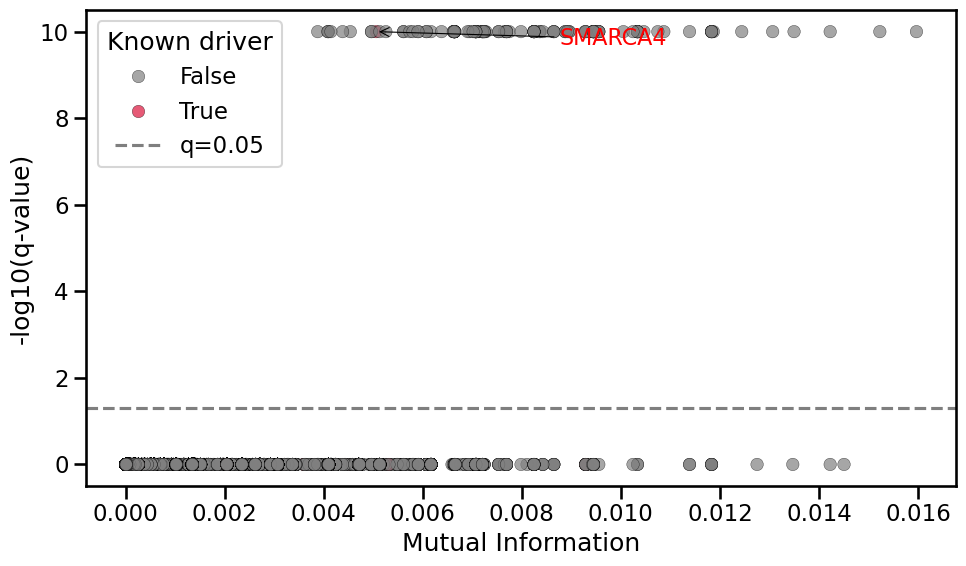

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Scatter plot visualization of q_val vs. mutual info
mi_df['is_driver'] = mi_df['gene'].isin(driver_genes)
mi_df['log_q'] = -np.log10(mi_df['q_value'] + 1e-10)

sns.set_context('talk')
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=mi_df,
    x='mutual_info',
    y='log_q',
    hue='is_driver',
    palette={True: 'crimson', False: 'gray'},
    edgecolor='black',
    linewidth=0.3,
    alpha=0.7
)

texts = []
for _, row in mi_df[(mi_df['is_driver']) & (mi_df['q_value'] < 0.05)].iterrows():
    texts.append(
        plt.annotate(
            row['gene'],
            xy=(row['mutual_info'], row['log_q']),
            xytext=(row['mutual_info'] + 0.01, row['log_q'] + 0.5),
            textcoords='data',
            fontsize=16,
            ha='left',
            va='bottom',
            color='red',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8)
        )
    )

adjust_text(texts)

plt.xlabel("Mutual Information")
plt.ylabel("-log10(q-value)")
plt.axhline(-np.log10(0.05), ls='--', color='black', alpha=0.5, label='q=0.05')
plt.legend(title="Known driver")
plt.tight_layout()
plt.show()

/var/folders/1c/p3sgf2gd2r50t_csxf8vrdv80000gn/T/ipykernel_30021/1923558854.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig_genes_df['is_driver'] = sig_genes_df['gene'].isin(driver_genes)


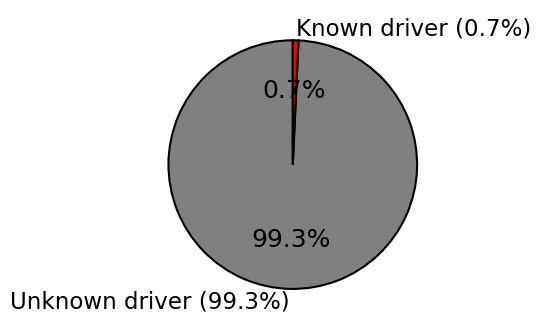

In [17]:
# Visualize number of "top gene mutations" by mutual info are known driver genes (IntOGene)
sig_genes_df = mi_df[mi_df['q_value'] < 0.05]
sig_genes_df['is_driver'] = sig_genes_df['gene'].isin(driver_genes)
driver_counts = sig_genes_df['is_driver'].value_counts().rename(index={True: 'Known driver', False: 'Unknown driver'})
percentages = driver_counts / driver_counts.sum() * 100

plt.figure(figsize=(5, 5))
plt.pie(
    driver_counts,
    labels=[f"{label} ({percent:.1f}%)" for label, percent in zip(driver_counts.index, percentages)],
    autopct='%1.1f%%',
    startangle=90,
    colors=['grey','red'],
    wedgeprops={'edgecolor': 'black'}
)
plt.tight_layout()
plt.show()


In [18]:
# Store top significant "driver" genes
sig_genes_df.to_csv('/Users/aleyshachen/BENG_285/proj_4/sig_mutations_driver_genes_MI.csv')